# Classification: Decision Tree (scikit-learn)

This notebook builds a survival classifier using a **single Decision Tree** on the classic [Titanic dataset](https://www.kaggle.com/c/titanic) — 891 passengers with a mix of numeric and categorical features (class, sex, age, fare, etc.) and a binary label: did the passenger survive?

End-to-end pipeline:
1. Get the data
2. Profile the data
3. Clean the data
4. Transform the data (encode categoricals — no scaling needed for trees)
5. Split into train / validation / test
6. Build the model: a single Decision Tree
7. Tune the key hyperparameter (`max_depth`) using the validation set
8. Final evaluation on the held-out test set
9. Visualize the tree and feature importances
10. Inference on a new, unseen passenger
11. Save the model

## 0. Install & Import Libraries

In [1]:
# !pip install scikit-learn pandas numpy matplotlib seaborn joblib --quiet

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, roc_curve,
)
import joblib

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Libraries loaded.")


Libraries loaded.


## 1. Get the Data

Loading the dataset from a local cache under `data/` if it exists; otherwise downloading it from the public source below and saving a local copy for next time:

`https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv`

Each row is one passenger; the target column is `Survived` (`0` = died, `1` = survived).

In [2]:
DATA_URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
DATA_DIR = "data"
LOCAL_PATH = os.path.join(DATA_DIR, "titanic.csv")

os.makedirs(DATA_DIR, exist_ok=True)

if os.path.exists(LOCAL_PATH):
    print(f"Loading data from local cache: {LOCAL_PATH}")
    df_raw = pd.read_csv(LOCAL_PATH)
else:
    print(f"Local file not found. Downloading from {DATA_URL} ...")
    df_raw = pd.read_csv(DATA_URL)
    df_raw.to_csv(LOCAL_PATH, index=False)
    print(f"Saved local copy to: {LOCAL_PATH}")

print("Shape:", df_raw.shape)
df_raw.head()


Local file not found. Downloading from https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv ...
Saved local copy to: data\titanic.csv
Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Profile the Data

Look at structure, types, missingness, and class balance before touching anything.

In [3]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
print("Survival distribution:")
print(df_raw["Survived"].value_counts(normalize=True).rename("proportion"))

print("\nNull count per column:")
print(df_raw.isna().sum())


Survival distribution:
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Null count per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


`Age` has a lot of missing values, `Cabin` is missing for most passengers, and `Embarked` is missing for a couple. `PassengerId`, `Name`, and `Ticket` are unique/near-unique identifiers with no real predictive value — same reasoning as dropping `customerID` in the churn notebook: a distance-free tree can still overfit to spurious per-row identifiers, so they're dropped.

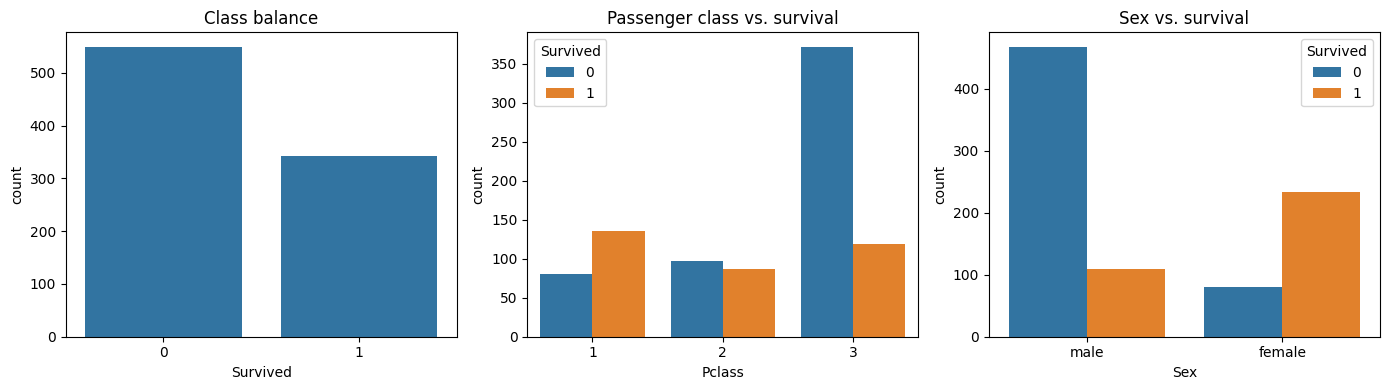

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.countplot(data=df_raw, x="Survived", ax=axes[0])
axes[0].set_title("Class balance")

sns.countplot(data=df_raw, x="Pclass", hue="Survived", ax=axes[1])
axes[1].set_title("Passenger class vs. survival")

sns.countplot(data=df_raw, x="Sex", hue="Survived", ax=axes[2])
axes[2].set_title("Sex vs. survival")

plt.tight_layout()
plt.show()


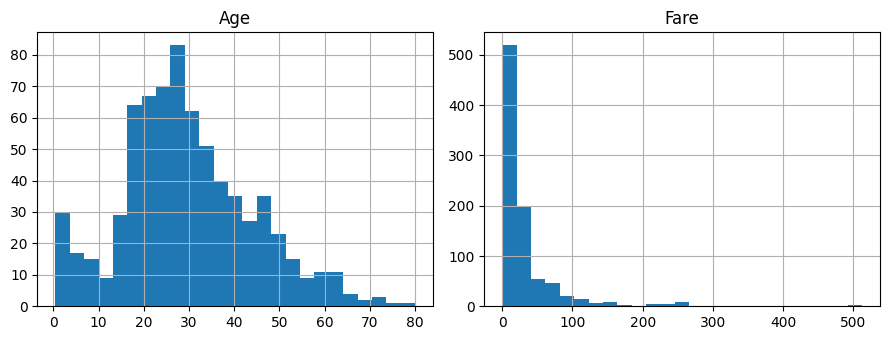

In [6]:
numeric_preview = ["Age", "Fare"]
df_raw[numeric_preview].hist(figsize=(9, 3.5), bins=25)
plt.tight_layout()
plt.show()


## 3. Clean the Data

Issues surfaced in profiling:
1. **`PassengerId`, `Name`, `Ticket`** — unique/near-unique identifiers with no predictive value, dropped.
2. **`Cabin`** — missing for ~77% of passengers. Too sparse to impute meaningfully, dropped.
3. **`Age`** — missing for ~20% of passengers, but likely predictive (children were prioritized). Kept, missing values imputed in the transform step (fit on train only).
4. **`Embarked`** — missing for just 2 rows. Kept, imputed with the most frequent port in the transform step.
5. **Duplicate rows** — checked and dropped if any exist.

In [7]:
df = df_raw.copy()

# 1. Check for true duplicate passengers FIRST, while unique identifiers
#    (PassengerId, Name, Ticket) are still present -- checking after dropping
#    them would flag coincidental feature matches (e.g. two different men,
#    both 62, 1st class, no family, same fare) as false-positive "duplicates".
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(df)} true duplicate rows -> {len(df)} rows remaining")

# 2. Now drop identifier / low-value columns
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

print("\nRemaining missing values (to be imputed later, fit on train only):")
print(df.isna().sum()[df.isna().sum() > 0])


Dropped 0 true duplicate rows -> 891 rows remaining

Remaining missing values (to be imputed later, fit on train only):
Age         177
Embarked      2
dtype: int64


## 4. Transform the Data: Encode Categoricals

Unlike KNN, a Decision Tree doesn't measure distance between points, so **feature scaling isn't necessary** — a tree just asks yes/no threshold questions per feature ("is `Age` <= 12?"), which is completely unaffected by the units or range a feature is measured in.

We still need to **encode categorical features** (`Sex`, `Embarked`) into numeric form, since scikit-learn's tree implementation requires numeric input, and **impute missing values** (`Age`, `Embarked`).

In [8]:
target_col = "Survived"
feature_cols = [c for c in df.columns if c != target_col]
numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]
categorical_features = [c for c in feature_cols if c not in numeric_features]

print("Numeric features    :", numeric_features)
print("Categorical features:", categorical_features)


Numeric features    : ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical features: ['Sex', 'Embarked']


In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

preprocessor


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 5. Split into Train / Validation / Test (one-time random split)

Carve off the test set first (held out completely until the final evaluation), then split the remainder into train/validation. We stratify by `Survived` at every step to keep class balance consistent across splits.

In [10]:
X = df[numeric_features + categorical_features]
y = df[target_col]

TEST_SIZE = 0.2
VAL_SIZE = 0.1

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y,
)

val_fraction_of_temp = VAL_SIZE / (1 - TEST_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_fraction_of_temp, random_state=SEED, stratify=y_temp,
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Train: (623, 7), Val: (89, 7), Test: (179, 7)


In [11]:
# Fit the preprocessor on TRAIN ONLY, then transform all three splits
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

feature_names_out = preprocessor.get_feature_names_out()
print("Processed feature count:", len(feature_names_out))
print(feature_names_out)


Processed feature count: 10
['num__Pclass' 'num__Age' 'num__SibSp' 'num__Parch' 'num__Fare'
 'cat__Sex_female' 'cat__Sex_male' 'cat__Embarked_C' 'cat__Embarked_Q'
 'cat__Embarked_S']


## 6. Build the Model: A Single Decision Tree

A Decision Tree learns a sequence of yes/no questions on individual features (e.g. "is `Sex_male` <= 0.5?", "is `Age` <= 6.5?") that progressively split the data into purer and purer groups with respect to the target.

Unlike KNN, this model actually has a real "training" step: it greedily picks the feature/threshold split that most reduces impurity (Gini by default) at each node, recursively, until a stopping condition is hit (e.g. max depth, or all leaves are pure).

In [12]:
baseline_model = DecisionTreeClassifier(random_state=SEED)
baseline_model.fit(X_train_proc, y_train)

train_preds = baseline_model.predict(X_train_proc)
val_preds = baseline_model.predict(X_val_proc)

print("Baseline (no depth limit) train accuracy     :", round(accuracy_score(y_train, train_preds), 4))
print("Baseline (no depth limit) validation accuracy:", round(accuracy_score(y_val, val_preds), 4))
print("Tree depth grown:", baseline_model.get_depth())


Baseline (no depth limit) train accuracy     : 0.9856
Baseline (no depth limit) validation accuracy: 0.809
Tree depth grown: 20


Notice the gap between train and validation accuracy: an unconstrained tree will keep splitting until every training leaf is pure, which means **train accuracy hits (near) 100%** — this is the same kind of "trivially perfect on training data" artifact you saw with `weights="distance"` in the KNN notebook, just caused by unlimited tree growth instead of a distance-zero self-match. It's a classic sign of overfitting, not genuine skill.

## 7. Tune the Key Hyperparameter: `max_depth`

Sweep `max_depth` across a range and track train vs. validation accuracy — the deeper the tree, the more it memorizes noise in the training data rather than learning generalizable patterns.

In [13]:
depth_values = list(range(1, 21))
results = []

for depth in depth_values:
    model = DecisionTreeClassifier(max_depth=depth, random_state=SEED)
    model.fit(X_train_proc, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train_proc))
    val_acc = accuracy_score(y_val, model.predict(X_val_proc))

    results.append({"max_depth": depth, "train_acc": train_acc, "val_acc": val_acc})

results_df = pd.DataFrame(results)
results_df


,max_depth,train_acc,val_acc
0,1,0.789727,0.786517
1,2,0.805778,0.797753
2,3,0.829856,0.853933
3,4,0.839486,0.842697
4,5,0.866774,0.842697
5,6,0.881220,0.820225
6,7,0.897271,0.853933
7,8,0.921348,0.842697
8,9,0.930979,0.842697
9,10,0.942215,0.842697


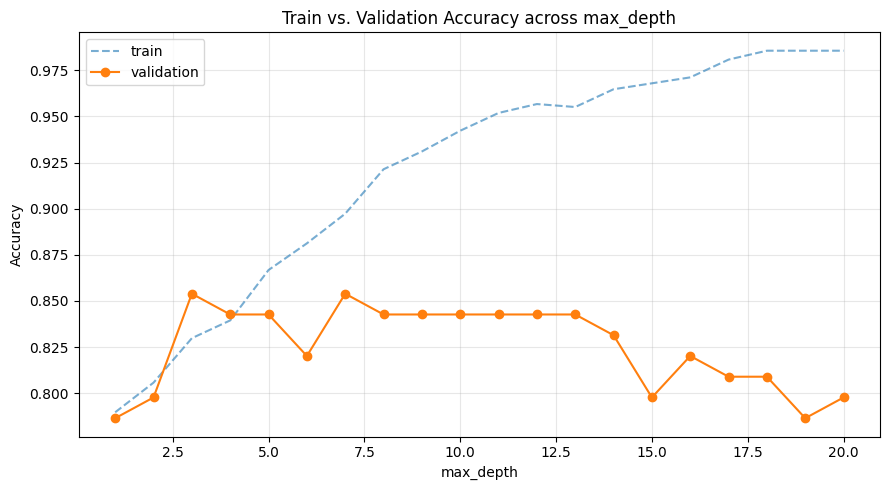

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(results_df["max_depth"], results_df["train_acc"], "--", alpha=0.6, label="train")
ax.plot(results_df["max_depth"], results_df["val_acc"], "-o", label="validation")

ax.set_xlabel("max_depth")
ax.set_ylabel("Accuracy")
ax.set_title("Train vs. Validation Accuracy across max_depth")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Rather than blindly picking the single `max_depth` with the highest validation accuracy (which can just be noise from a small validation set), we look for the **elbow**: the smallest `max_depth` where validation accuracy has essentially flattened out. A shallower tree that's within a small margin of the peak is preferable — it's simpler, more interpretable, and less likely to be overfit to validation-set noise (the same "one standard error rule" idea discussed for choosing `k` in the KNN notebook).

In [15]:
best_val_acc = results_df["val_acc"].max()
tolerance = 0.01  # within 1 percentage point of the peak counts as "just as good"

candidates = results_df[results_df["val_acc"] >= best_val_acc - tolerance]
best_row = candidates.sort_values("max_depth").iloc[0]  # simplest (shallowest) tree in that band

BEST_DEPTH = int(best_row["max_depth"])

print(f"Peak validation accuracy: {round(best_val_acc, 4)} (at max_depth={int(results_df.loc[results_df['val_acc'].idxmax(), 'max_depth'])})")
print(f"Elbow-selected max_depth: {BEST_DEPTH} (val accuracy: {round(best_row['val_acc'], 4)})")


Peak validation accuracy: 0.8539 (at max_depth=3)
Elbow-selected max_depth: 3 (val accuracy: 0.8539)


## 8. Final Evaluation on the Held-Out Test Set

The test set has not been touched until now. We refit on **train only** (keeping val available as an honest checkpoint) using the selected `max_depth`, then evaluate once on test.

In [16]:
final_model = DecisionTreeClassifier(max_depth=BEST_DEPTH, random_state=SEED)
final_model.fit(X_train_proc, y_train)

test_preds = final_model.predict(X_test_proc)
test_probs = final_model.predict_proba(X_test_proc)[:, 1]

print("Test accuracy :", round(accuracy_score(y_test, test_preds), 4))
print("Test precision:", round(precision_score(y_test, test_preds), 4))
print("Test recall   :", round(recall_score(y_test, test_preds), 4))
print("Test F1       :", round(f1_score(y_test, test_preds), 4))
print("Test ROC AUC  :", round(roc_auc_score(y_test, test_probs), 4))
print()
print(classification_report(y_test, test_preds, target_names=["died", "survived"]))


Test accuracy : 0.7933
Test precision: 0.8636
Test recall   : 0.5507
Test F1       : 0.6726
Test ROC AUC  : 0.8113

              precision    recall  f1-score   support

        died       0.77      0.95      0.85       110
    survived       0.86      0.55      0.67        69

    accuracy                           0.79       179
   macro avg       0.82      0.75      0.76       179
weighted avg       0.81      0.79      0.78       179



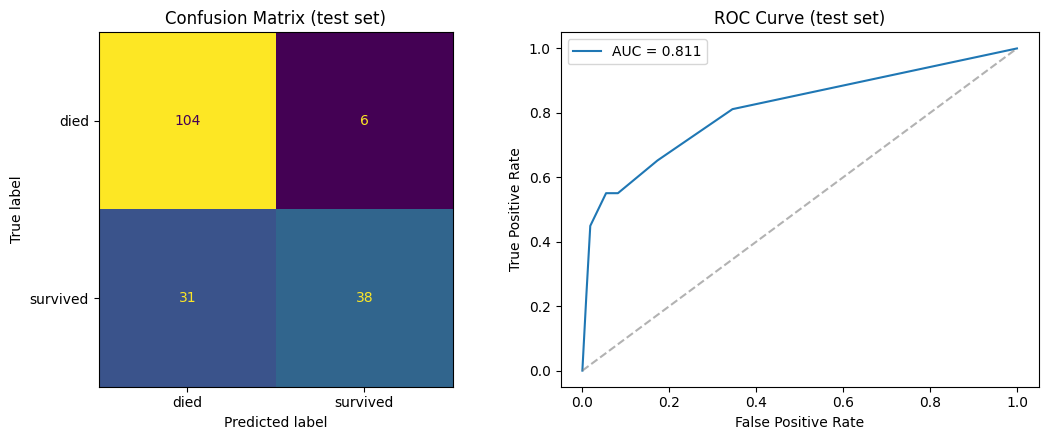

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm = confusion_matrix(y_test, test_preds)
ConfusionMatrixDisplay(cm, display_labels=["died", "survived"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix (test set)")

fpr, tpr, _ = roc_curve(y_test, test_probs)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, test_probs):.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray", alpha=0.6)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve (test set)")
axes[1].legend()

plt.tight_layout()
plt.show()


## 9. Visualize the Tree and Feature Importances

A key advantage of a single Decision Tree over KNN: it's directly **interpretable**. You can read off the exact sequence of yes/no questions that led to any prediction, and rank features by how much they contributed to reducing impurity overall.

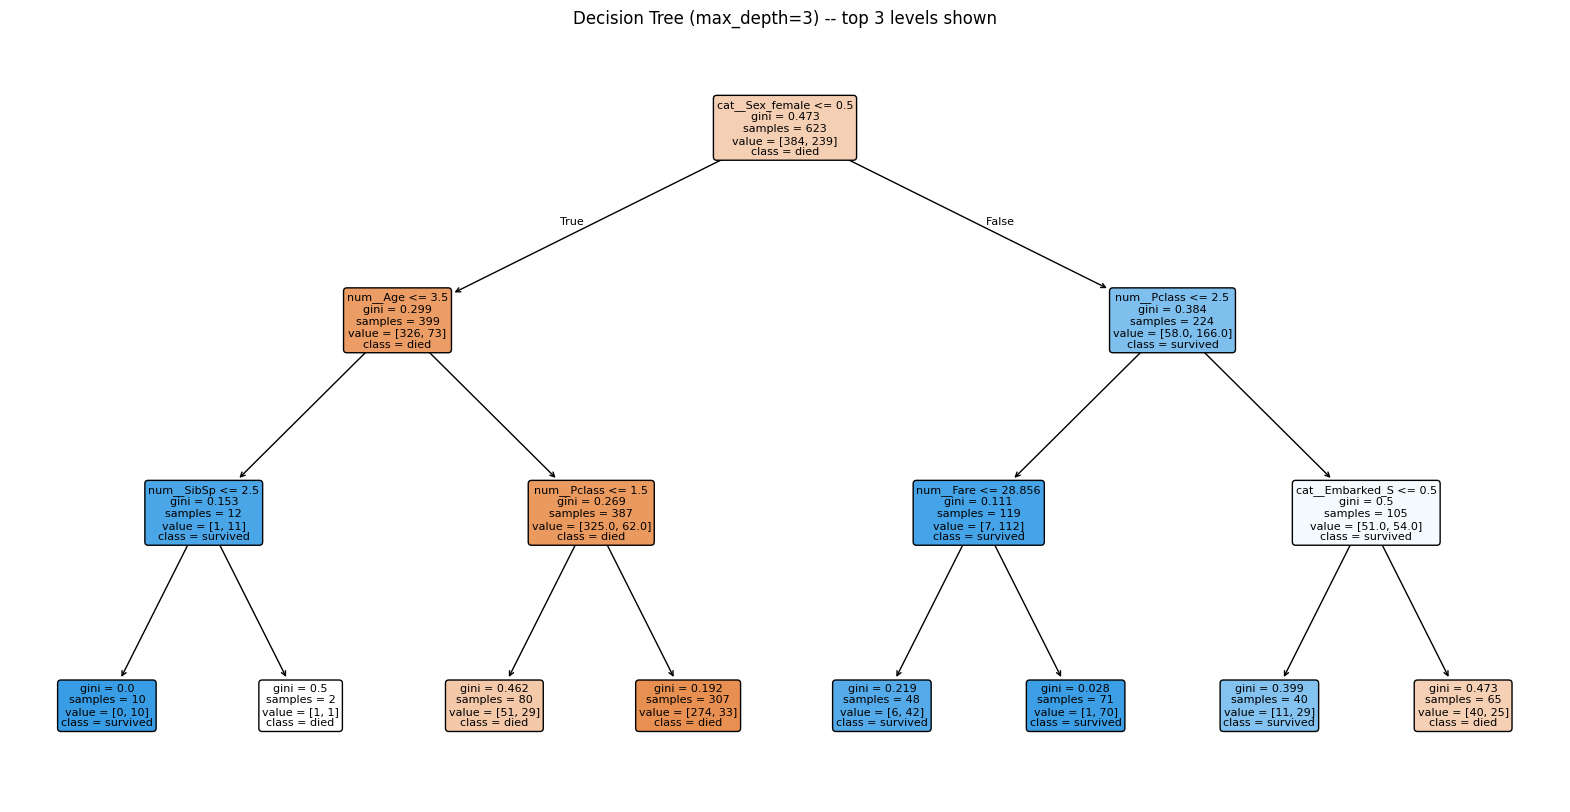

In [18]:
plt.figure(figsize=(20, 10))
plot_tree(
    final_model,
    feature_names=feature_names_out,
    class_names=["died", "survived"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3,  # show only the top levels for readability; the full tree may be deeper
)
plt.title(f"Decision Tree (max_depth={BEST_DEPTH}) -- top 3 levels shown")
plt.show()


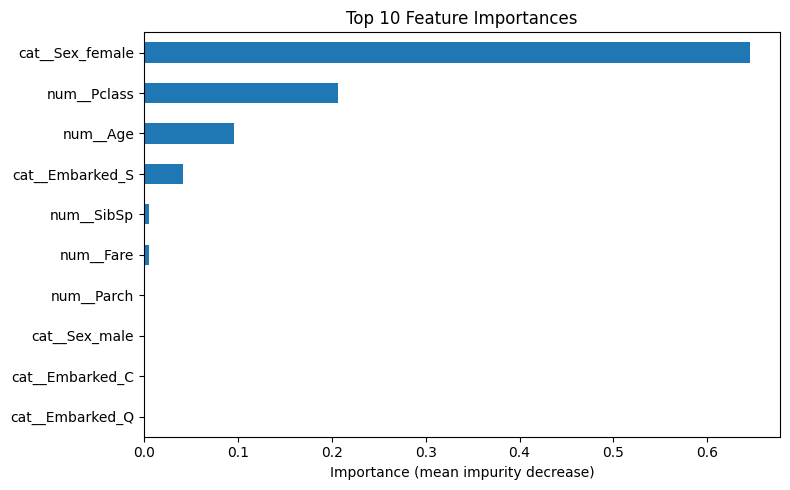

In [19]:
importances = pd.Series(final_model.feature_importances_, index=feature_names_out).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
importances.head(10).plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_xlabel("Importance (mean impurity decrease)")
ax.set_title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()


## 10. Inference on a New, Unseen Passenger

A new passenger is just a raw dict of feature values -> it must go through the **exact same fitted `preprocessor`** (impute -> one-hot) before it can be fed to the model.

In [20]:
def predict_survival(raw_features: dict, model, preprocessor):
    # raw_features: dict with keys matching the original column names
    input_df = pd.DataFrame([raw_features])
    input_proc = preprocessor.transform(input_df)
    pred = model.predict(input_proc)[0]
    prob = model.predict_proba(input_proc)[0, 1]
    return pred, prob


example_passenger = {
    "Pclass": 3,
    "Sex": "male",
    "Age": 22,
    "SibSp": 1,
    "Parch": 0,
    "Fare": 7.25,
    "Embarked": "S",
}

pred, prob = predict_survival(example_passenger, final_model, preprocessor)
print(f"Predicted: {'survived' if pred == 1 else 'died'} (P(survived) = {prob:.3f})")


Predicted: died (P(survived) = 0.107)


## 11. Save the Model (optional)

In [21]:
joblib.dump({"model": final_model, "preprocessor": preprocessor}, "titanic_tree_classifier.joblib")
print("Model + preprocessor saved to titanic_tree_classifier.joblib")

# To reload later:
# bundle = joblib.load("titanic_tree_classifier.joblib")
# final_model, preprocessor = bundle["model"], bundle["preprocessor"]


Model + preprocessor saved to titanic_tree_classifier.joblib
